[Series of audio signal processing for ML](https://www.youtube.com/watch?v=iCwMQJnKk2c&list=PL-wATfeyAMNqIee7cH3q1bh4QJFAaeNv0)

[Short-time Fourier Transform](https://www.youtube.com/watch?v=-Yxj3yfvY-4&list=PL-wATfeyAMNqIee7cH3q1bh4QJFAaeNv0&index=15)

[Video](https://www.youtube.com/watch?v=9GHCiiDLHQ4) to understand mel-spectrogram  
mel <- melody
$$m = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$
$$f = 700\left(10^\frac{m}{2595}-1\right)$$

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import torchaudio
import torch
import torchaudio.transforms as T
import soundfile as sf
print(f'Cuda available: {torch.cuda.is_available()}')
print(f'Cuda device name: {torch.cuda.get_device_name(0)}')


Cuda available: True
Cuda device name: NVIDIA GeForce RTX 2060


In [2]:
files = list(Path('../data').rglob('*.ogg'))
print(f'Number of .ogg files: {len(files)}')

Number of .ogg files: 46207


In [3]:

SAMPLE_RATE = sf.info(str(files[0])).samplerate
N_FFT=1024
HOP_LENGTH = 512
F_MIN = 500
F_MAX = 16000
N_MELS =  128
print(f'Sample rate of .ogg files: {SAMPLE_RATE} Hz')

mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    win_length=None,
    hop_length=HOP_LENGTH,
    f_min=F_MIN,
    f_max=F_MAX,
    n_mels=N_MELS,
    window_fn=torch.hamming_window
)

Sample rate of .ogg files: 32000 Hz


In [4]:
waveform, _ = torchaudio.load(str(files[0])) 

Mel spectrogram db shape: torch.Size([1, 128, 3751])


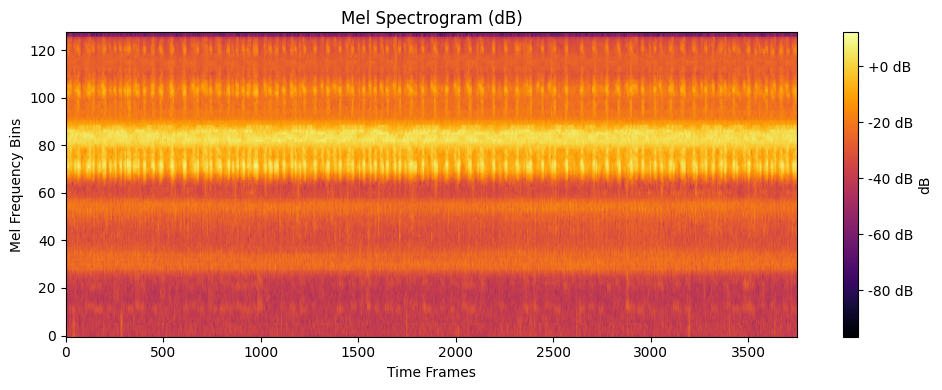

In [5]:
mel_spec = mel_transform(waveform)
mel_spec_db = T.AmplitudeToDB()(mel_spec)
print(f'Mel spectrogram db shape: {mel_spec_db.shape}')
plt.figure(figsize=(10, 4))
plt.imshow(mel_spec_db[0].numpy(), origin='lower', aspect='auto', cmap='inferno')
plt.colorbar(format='%+2.0f dB', label='dB')
plt.xlabel('Time Frames')
plt.ylabel('Mel Frequency Bins')
plt.title('Mel Spectrogram (dB)')
plt.tight_layout()
plt.show()